# 🎬 Movie Sentiment Analysis
**Goal:** Classify IMDB movie reviews as *positive* or *negative* using Naive Bayes classifiers.

**Pipeline:**
1. Load & explore data
2. Text preprocessing (HTML cleaning → lowercase → stemming → stopword removal)
3. Feature extraction (Bag of Words & TF-IDF)
4. Model training & evaluation (GaussianNB, MultinomialNB, BernoulliNB)
5. Predict sentiment on custom reviews

## 📦 Section 1 — Import Libraries

In [1]:
# Standard data manipulation & numerical libraries
import numpy as np
import pandas as pd
import re

# Visualisation
import seaborn as sns
import matplotlib.pyplot as plt

# NLP utilities
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

# Feature extraction
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Machine-learning models
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    confusion_matrix,
    classification_report,
)

# Download required NLTK data (only needed once)
nltk.download("stopwords", quiet=True)

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


## 📂 Section 2 — Load & Explore Data
The IMDB dataset contains **50,000 movie reviews**, labelled *positive* or *negative*.

In [2]:
# Load the dataset — place 'IMDB Dataset.csv' inside the Data/ folder
df = pd.read_csv("Data/IMDB Dataset.csv")

print(f"Dataset shape: {df.shape}")
print(f"Columns      : {df.columns.tolist()}")
df.head()

Dataset shape: (50000, 2)
Columns      : ['review', 'sentiment']


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
# Quick structural overview — dtypes, null counts, memory usage
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB


Sentiment counts:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


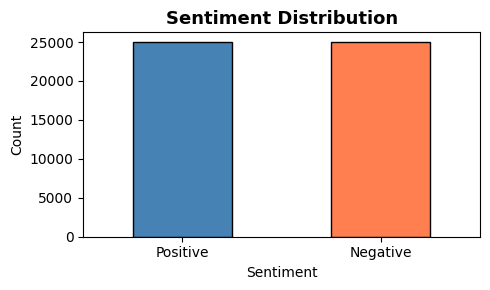

In [4]:
# Check class distribution — ideally 50/50 for balanced training
print("Sentiment counts:")
print(df["sentiment"].value_counts())

# Bar chart of sentiment distribution
fig, ax = plt.subplots(figsize=(5, 3))
df["sentiment"].value_counts().plot(kind="bar", ax=ax, color=["steelblue", "coral"], edgecolor="black")
ax.set_title("Sentiment Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Count")
ax.set_xticklabels(["Positive", "Negative"], rotation=0)
plt.tight_layout()
plt.show()

In [5]:
# Inspect a raw review to understand what preprocessing is needed
print("Sample raw review:")
print("-" * 60)
print(df["review"].iloc[0])

Sample raw review:
------------------------------------------------------------
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are neve

## ✂️ Section 3 — Sampling & Label Encoding
Working with the full 50k rows is slow during prototyping.  
We sample **10,000 reviews** with a fixed `random_state` so results are reproducible.

In [6]:
# Sample 10,000 rows — random_state=42 ensures the same subset every run
df = df.sample(10_000, random_state=42).reset_index(drop=True)

print(f"Sampled dataset shape: {df.shape}")

Sampled dataset shape: (10000, 2)


In [7]:
# Encode the target column: positive → 1, negative → 0
# Using .map() avoids the FutureWarning raised by .replace(..., inplace=True)
df["sentiment"] = df["sentiment"].map({"positive": 1, "negative": 0})

print("Label encoding complete.")
print(df["sentiment"].value_counts())
df.head()

Label encoding complete.
sentiment
1    5039
0    4961
Name: count, dtype: int64


,review,sentiment
0,I really liked this Summerslam due to the look...,1
1,Not many television shows appeal to quite as m...,1
2,The film quickly gets to a major chase scene w...,0
3,Jane Austen would definitely approve of this o...,1
4,Expectations were somewhat high for me when I ...,0


## 🧹 Section 4 — Text Preprocessing
Raw reviews contain HTML tags, mixed case, punctuation, stopwords, and inflected words.  
We clean them step by step before feeding them to a vectoriser.

| Step | What it does |
|------|-------------|
| Strip HTML | Removes `<br />` and other tags |
| Lowercase | Normalises casing (`The` = `the`) |
| Remove special chars | Replaces punctuation with spaces |
| Remove stopwords | Drops common words ("the", "is", …) |
| Stemming | Reduces words to root form (`running` → `run`) |

In [8]:
# ── Step 1: Strip HTML tags ─────────────────────────────────────────────
# Regex pattern matches any <...> tag and replaces it with an empty string
_html_pattern = re.compile("<.*?>")

def clean_html(text: str) -> str:
    """Remove HTML tags from a string."""
    return re.sub(_html_pattern, "", text)

# Quick sanity check
sample = df["review"].iloc[0]
print("Before:", sample[:120])
print("After :", clean_html(sample)[:120])

Before: I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to m
After : I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to m


In [9]:
# Apply HTML cleaning to every review
df["review"] = df["review"].apply(clean_html)
print("✅ HTML tags removed.")

✅ HTML tags removed.


In [10]:
# ── Step 2: Convert to lowercase ────────────────────────────────────────
def convert_lower(text: str) -> str:
    """Lowercase the entire string."""
    return text.lower()

df["review"] = df["review"].apply(convert_lower)
print("✅ Text lowercased.")

✅ Text lowercased.


In [11]:
# ── Step 3: Remove special characters ───────────────────────────────────
# Keep only alphanumeric characters; replace everything else with a space
def remove_special(text: str) -> str:
    """Replace non-alphanumeric characters with spaces."""
    return "".join(ch if ch.isalnum() else " " for ch in text)

df["review"] = df["review"].apply(remove_special)
print("✅ Special characters removed.")

✅ Special characters removed.


In [12]:
# ── Step 4: Remove stopwords ────────────────────────────────────────────
# Stopwords ("the", "is", "in", …) carry little sentiment signal
_stop_words = set(stopwords.words("english"))

def remove_stopwords(text: str) -> list:
    """Split text into tokens and drop English stopwords.
    Returns a list of meaningful tokens.
    """
    return [word for word in text.split() if word not in _stop_words]

df["review"] = df["review"].apply(remove_stopwords)
print("✅ Stopwords removed.")
print("Sample token list:", df["review"].iloc[0][:10])

✅ Stopwords removed.
Sample token list: ['really', 'liked', 'summerslam', 'due', 'look', 'arena', 'curtains', 'look', 'overall', 'interesting']


In [13]:
# ── Step 5: Stemming ────────────────────────────────────────────────────
# PorterStemmer reduces words to their root form:
#   "running" → "run", "movies" → "movi"
ps = PorterStemmer()

def stem_words(tokens: list) -> list:
    """Apply Porter stemming to a list of tokens."""
    return [ps.stem(word) for word in tokens]

df["review"] = df["review"].apply(stem_words)
print("✅ Stemming applied.")
print("Sample stemmed tokens:", df["review"].iloc[0][:10])

✅ Stemming applied.
Sample stemmed tokens: ['realli', 'like', 'summerslam', 'due', 'look', 'arena', 'curtain', 'look', 'overal', 'interest']


In [14]:
# ── Step 6: Rejoin tokens into a single string ──────────────────────────
# Scikit-learn vectorisers expect strings, not lists
def join_back(tokens: list) -> str:
    """Join a list of tokens back into a whitespace-separated string."""
    return " ".join(tokens)

df["review"] = df["review"].apply(join_back)
print("✅ Tokens rejoined into strings.")
print("Sample cleaned review:")
print(df["review"].iloc[0][:200])

✅ Tokens rejoined into strings.
Sample cleaned review:
realli like summerslam due look arena curtain look overal interest reason anyway could one best summerslam ever wwf lex luger main event yokozuna time ok huge fat man vs strong man glad time chang ter


## 🔢 Section 5 — Feature Extraction: Bag of Words (CountVectorizer)
CountVectorizer converts each review into a **word-count vector**.  
`max_features=1000` keeps only the 1,000 most frequent words to control dimensionality.

In [15]:
# Build the Bag-of-Words matrix
# Each row = one review, each column = a word, each value = word count
cv = CountVectorizer(max_features=1000)
X_bow = cv.fit_transform(df["review"]).toarray()

# Extract target labels
y = df["sentiment"].values

print(f"Feature matrix shape : {X_bow.shape}  (reviews × vocabulary)")
print(f"Target vector shape  : {y.shape}")

Feature matrix shape : (10000, 1000)  (reviews × vocabulary)
Target vector shape  : (10000,)


In [16]:
# Split into training (80%) and test (20%) sets
# random_state=42 makes the split reproducible
X_train_bow, X_test_bow, y_train, y_test = train_test_split(
    X_bow, y, test_size=0.2, random_state=42
)

print(f"Training samples : {X_train_bow.shape[0]}")
print(f"Test samples     : {X_test_bow.shape[0]}")

Training samples : 8000
Test samples     : 2000


## 🤖 Section 6 — Model Training: Naive Bayes Variants
We compare three Naive Bayes flavours on the Bag-of-Words features:

| Model | Best for |
|-------|---------|
| **GaussianNB** | Continuous / normally distributed features |
| **MultinomialNB** | Discrete counts (word frequencies) ✅ |
| **BernoulliNB** | Binary presence/absence of words |

In [17]:
# Initialise all three classifiers
clf_gaussian    = GaussianNB()
clf_multinomial = MultinomialNB()
clf_bernoulli   = BernoulliNB()

# Train each model on the BoW training data
clf_gaussian.fit(X_train_bow, y_train)
clf_multinomial.fit(X_train_bow, y_train)
clf_bernoulli.fit(X_train_bow, y_train)

print("✅ All three models trained.")

✅ All three models trained.


In [18]:
# Generate predictions for each model on the held-out test set
y_pred_gaussian    = clf_gaussian.predict(X_test_bow)
y_pred_multinomial = clf_multinomial.predict(X_test_bow)
y_pred_bernoulli   = clf_bernoulli.predict(X_test_bow)

print("✅ Predictions generated.")

✅ Predictions generated.


## 📊 Section 7 — Model Evaluation
We measure **accuracy** and **precision** for each model, then inspect the best model's confusion matrix and full classification report.

In [19]:
# ── Accuracy & Precision summary table ──────────────────────────────────
results = {
    "Model": ["GaussianNB", "MultinomialNB", "BernoulliNB"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_gaussian),
        accuracy_score(y_test, y_pred_multinomial),
        accuracy_score(y_test, y_pred_bernoulli),
    ],
    "Precision": [
        precision_score(y_test, y_pred_gaussian),
        precision_score(y_test, y_pred_multinomial),
        precision_score(y_test, y_pred_bernoulli),
    ],
}

results_df = pd.DataFrame(results).set_index("Model")
results_df = results_df.round(4).sort_values("Accuracy", ascending=False)

print("BoW Model Comparison:")
print(results_df.to_string())

BoW Model Comparison:
               Accuracy  Precision
Model                             
BernoulliNB      0.8350     0.8273
MultinomialNB    0.8255     0.8286
GaussianNB       0.7820     0.8108


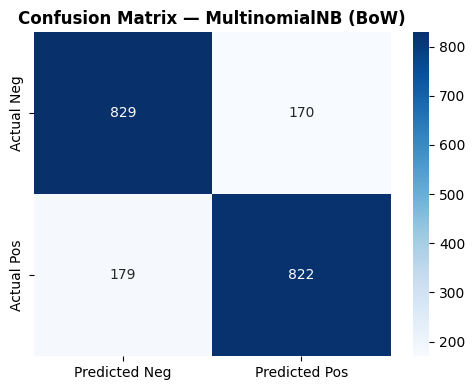

In [20]:
# ── Confusion Matrix for best BoW model (MultinomialNB) ─────────────────
cm = confusion_matrix(y_test, y_pred_multinomial)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Predicted Neg", "Predicted Pos"],
    yticklabels=["Actual Neg", "Actual Pos"],
    ax=ax,
)
ax.set_title("Confusion Matrix — MultinomialNB (BoW)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

In [21]:
# ── Full classification report ──────────────────────────────────────────
# Shows precision, recall, and F1-score for each class
print("Classification Report — MultinomialNB (BoW):")
print("-" * 50)
print(classification_report(y_test, y_pred_multinomial, target_names=["Negative", "Positive"]))

Classification Report — MultinomialNB (BoW):
--------------------------------------------------
              precision    recall  f1-score   support

    Negative       0.82      0.83      0.83       999
    Positive       0.83      0.82      0.82      1001

    accuracy                           0.83      2000
   macro avg       0.83      0.83      0.83      2000
weighted avg       0.83      0.83      0.83      2000



## 🔢 Section 8 — Feature Extraction: TF-IDF
**TF-IDF** (Term Frequency–Inverse Document Frequency) down-weights very common words  
and up-weights words that are distinctive to specific reviews — often outperforming raw counts.

In [22]:
# Build TF-IDF matrix with the same vocabulary size as BoW for fair comparison
tfidf = TfidfVectorizer(max_features=1000)
X_tfidf = tfidf.fit_transform(df["review"]).toarray()

# Re-use the same y labels; split with the same seed for a fair comparison
X_train_tfidf, X_test_tfidf, y_train_t, y_test_t = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

print(f"TF-IDF feature matrix shape: {X_tfidf.shape}")

TF-IDF feature matrix shape: (10000, 1000)


## 🤖 Section 9 — Model Training & Evaluation: TF-IDF + MultinomialNB

In [23]:
# MultinomialNB works well with TF-IDF scores (non-negative floats)
model_tfidf = MultinomialNB()
model_tfidf.fit(X_train_tfidf, y_train_t)

y_pred_tfidf = model_tfidf.predict(X_test_tfidf)

tfidf_acc  = accuracy_score(y_test_t, y_pred_tfidf)
tfidf_prec = precision_score(y_test_t, y_pred_tfidf)

print(f"TF-IDF MultinomialNB — Accuracy : {tfidf_acc:.4f}")
print(f"TF-IDF MultinomialNB — Precision: {tfidf_prec:.4f}")
print()
print("Classification Report — MultinomialNB (TF-IDF):")
print("-" * 50)
print(classification_report(y_test_t, y_pred_tfidf, target_names=["Negative", "Positive"]))

TF-IDF MultinomialNB — Accuracy : 0.8330
TF-IDF MultinomialNB — Precision: 0.8254

Classification Report — MultinomialNB (TF-IDF):
--------------------------------------------------
              precision    recall  f1-score   support

    Negative       0.84      0.82      0.83       999
    Positive       0.83      0.85      0.84      1001

    accuracy                           0.83      2000
   macro avg       0.83      0.83      0.83      2000
weighted avg       0.83      0.83      0.83      2000



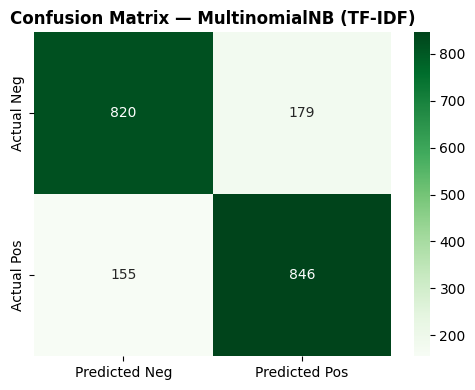

In [24]:
# ── Confusion Matrix for TF-IDF model ───────────────────────────────────
cm_tfidf = confusion_matrix(y_test_t, y_pred_tfidf)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm_tfidf, annot=True, fmt="d", cmap="Greens",
    xticklabels=["Predicted Neg", "Predicted Pos"],
    yticklabels=["Actual Neg", "Actual Pos"],
    ax=ax,
)
ax.set_title("Confusion Matrix — MultinomialNB (TF-IDF)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 🏆 Section 10 — Final Model Comparison

In [25]:
# Side-by-side accuracy comparison of all models
all_results = {
    "Model": [
        "GaussianNB (BoW)",
        "MultinomialNB (BoW)",
        "BernoulliNB (BoW)",
        "MultinomialNB (TF-IDF)",
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_gaussian),
        accuracy_score(y_test, y_pred_multinomial),
        accuracy_score(y_test, y_pred_bernoulli),
        tfidf_acc,
    ],
    "Precision": [
        precision_score(y_test, y_pred_gaussian),
        precision_score(y_test, y_pred_multinomial),
        precision_score(y_test, y_pred_bernoulli),
        tfidf_prec,
    ],
}

final_df = pd.DataFrame(all_results).set_index("Model").round(4)
final_df = final_df.sort_values("Accuracy", ascending=False)

print("=" * 55)
print("       📊 Final Model Comparison")
print("=" * 55)
print(final_df.to_string())
print("=" * 55)
print(f"\n🏆 Best model: {final_df['Accuracy'].idxmax()}")
print(f"   Accuracy  : {final_df['Accuracy'].max():.4f}")
print(f"   Precision : {final_df.loc[final_df['Accuracy'].idxmax(), 'Precision']:.4f}")

       📊 Final Model Comparison
                        Accuracy  Precision
Model                                      
BernoulliNB (BoW)         0.8350     0.8273
MultinomialNB (TF-IDF)    0.8330     0.8254
MultinomialNB (BoW)       0.8255     0.8286
GaussianNB (BoW)          0.7820     0.8108

🏆 Best model: BernoulliNB (BoW)
   Accuracy  : 0.8350
   Precision : 0.8273


## 🎯 Section 11 — Predict Sentiment on a Custom Review
Test the best model (TF-IDF + MultinomialNB) with your own text.

In [26]:
def predict_sentiment(review_text: str) -> str:
    """
    Predict the sentiment of a raw movie review string.

    Steps:
        1. Strip HTML tags
        2. Lowercase
        3. Remove special characters
        4. Remove stopwords
        5. Stem words
        6. Vectorise with the trained TF-IDF model
        7. Return 'Positive' or 'Negative'
    """
    # Apply the same preprocessing pipeline used during training
    text = clean_html(review_text)
    text = convert_lower(text)
    text = remove_special(text)
    tokens = remove_stopwords(text)
    tokens = stem_words(tokens)
    text = join_back(tokens)

    # Vectorise and predict
    vector = tfidf.transform([text]).toarray()
    prediction = model_tfidf.predict(vector)[0]

    return "✅ Positive" if prediction == 1 else "❌ Negative"


# ── Test with a few sample reviews ──────────────────────────────────────
test_reviews = [
    "This movie was absolutely fantastic! The acting was superb.",
    "Terrible film. Waste of time. I walked out halfway through.",
    "It was okay, nothing special but not bad either.",
]

print("Custom Review Predictions")
print("=" * 60)
for review in test_reviews:
    print(f"Review  : {review}")
    print(f"Verdict : {predict_sentiment(review)}")
    print("-" * 60)

Custom Review Predictions
Review  : This movie was absolutely fantastic! The acting was superb.
Verdict : ✅ Positive
------------------------------------------------------------
Review  : Terrible film. Waste of time. I walked out halfway through.
Verdict : ❌ Negative
------------------------------------------------------------
Review  : It was okay, nothing special but not bad either.
Verdict : ❌ Negative
------------------------------------------------------------
